# Hyperliquid Trader Behavior Analysis
## How Market Sentiment (Fear vs Greed Index) Shapes On-Chain Trading Behavior

**Project Type:**  Data Science Project

**Platform:** Hyperliquid (Decentralized Perpetuals Exchange)

**Objective:**
To explore how crypto market sentiment, measured by the Fear and Greed Index,
influences trader behavior and performance on Hyperliquid across 211,000+ trades.


In [56]:
import shutil
import os

shutil.make_archive("project_charts", "zip", "./charts")
print("Done. File ready:", os.path.getsize("project_charts.zip") / 1024, "KB")

Done. File ready: 982.41796875 KB


In [1]:
requirements = """pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scipy>=1.11.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt written.")

requirements.txt written.


In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date handling
from datetime import datetime

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Plot style
sns.set(style="whitegrid")

In [3]:
import os

BASE_DIR = "."

folders = [
    "data",
    "outputs",
    "charts"
]

for folder in folders:
    path = os.path.join(BASE_DIR, folder)
    if not os.path.exists(path):
        os.makedirs(path)

print("Project folders ready.")

Project folders ready.


In [5]:
fear_greed_df = pd.read_csv("./data/fear_greed_index.csv")
trader_df = pd.read_csv("./data/historical_data.csv")

print("Fear Greed Index shape:", fear_greed_df.shape)
print("Trader Data shape:", trader_df.shape)

fear_greed_df.head()

Fear Greed Index shape: (2644, 4)
Trader Data shape: (125831, 16)


/tmp/ipykernel_2506/338726751.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trader_df = pd.read_csv("./data/historical_data.csv")


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## EDA
We begin by examining the structure, data types, and missing values in both datasets.


In [6]:
fear_greed_df.info()
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125831 entries, 0 to 125830
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           125831 non-null  object 
 1   Coin              125831 non-null  object 
 2   Execution Price   125831 non-null  float64
 3   Size Tokens       125831 non-null  float64
 4   Size USD          125831 non-null  float64
 5   Side              125830 non-null  object 
 6   Timestamp IST     125830 non-null  object 
 7   Start Position    125830 non-nu

In [7]:
fear_greed_df.shape
trader_df.shape

(125831, 16)

In [8]:
fear_greed_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [9]:
trader_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [10]:
# Convert date column to datetime
fear_greed_df["date"] = pd.to_datetime(fear_greed_df["date"])

# Create a pure date column (no time)
fear_greed_df["trade_date"] = fear_greed_df["date"].dt.date

fear_greed_df.head()

,timestamp,value,classification,date,trade_date
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05


## Fear and Greed Index — Standalone Exploration

Before merging, we examine the Fear and Greed dataset independently to understand
the distribution of market sentiment from 2018 to present.

In [11]:
fear_greed_df["date"] = pd.to_datetime(fear_greed_df["date"])

print("Date range:", fear_greed_df["date"].min(), "to", fear_greed_df["date"].max())
print("Total days:", len(fear_greed_df))
print()
print("Sentiment distribution:")
print(fear_greed_df["classification"].value_counts())
print()
print("Value statistics:")
print(fear_greed_df["value"].describe())

Date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Total days: 2644

Sentiment distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Value statistics:
count   2644.0000
mean      46.9811
std       21.8277
min        5.0000
25%       28.0000
50%       46.0000
75%       66.0000
max       95.0000
Name: value, dtype: float64


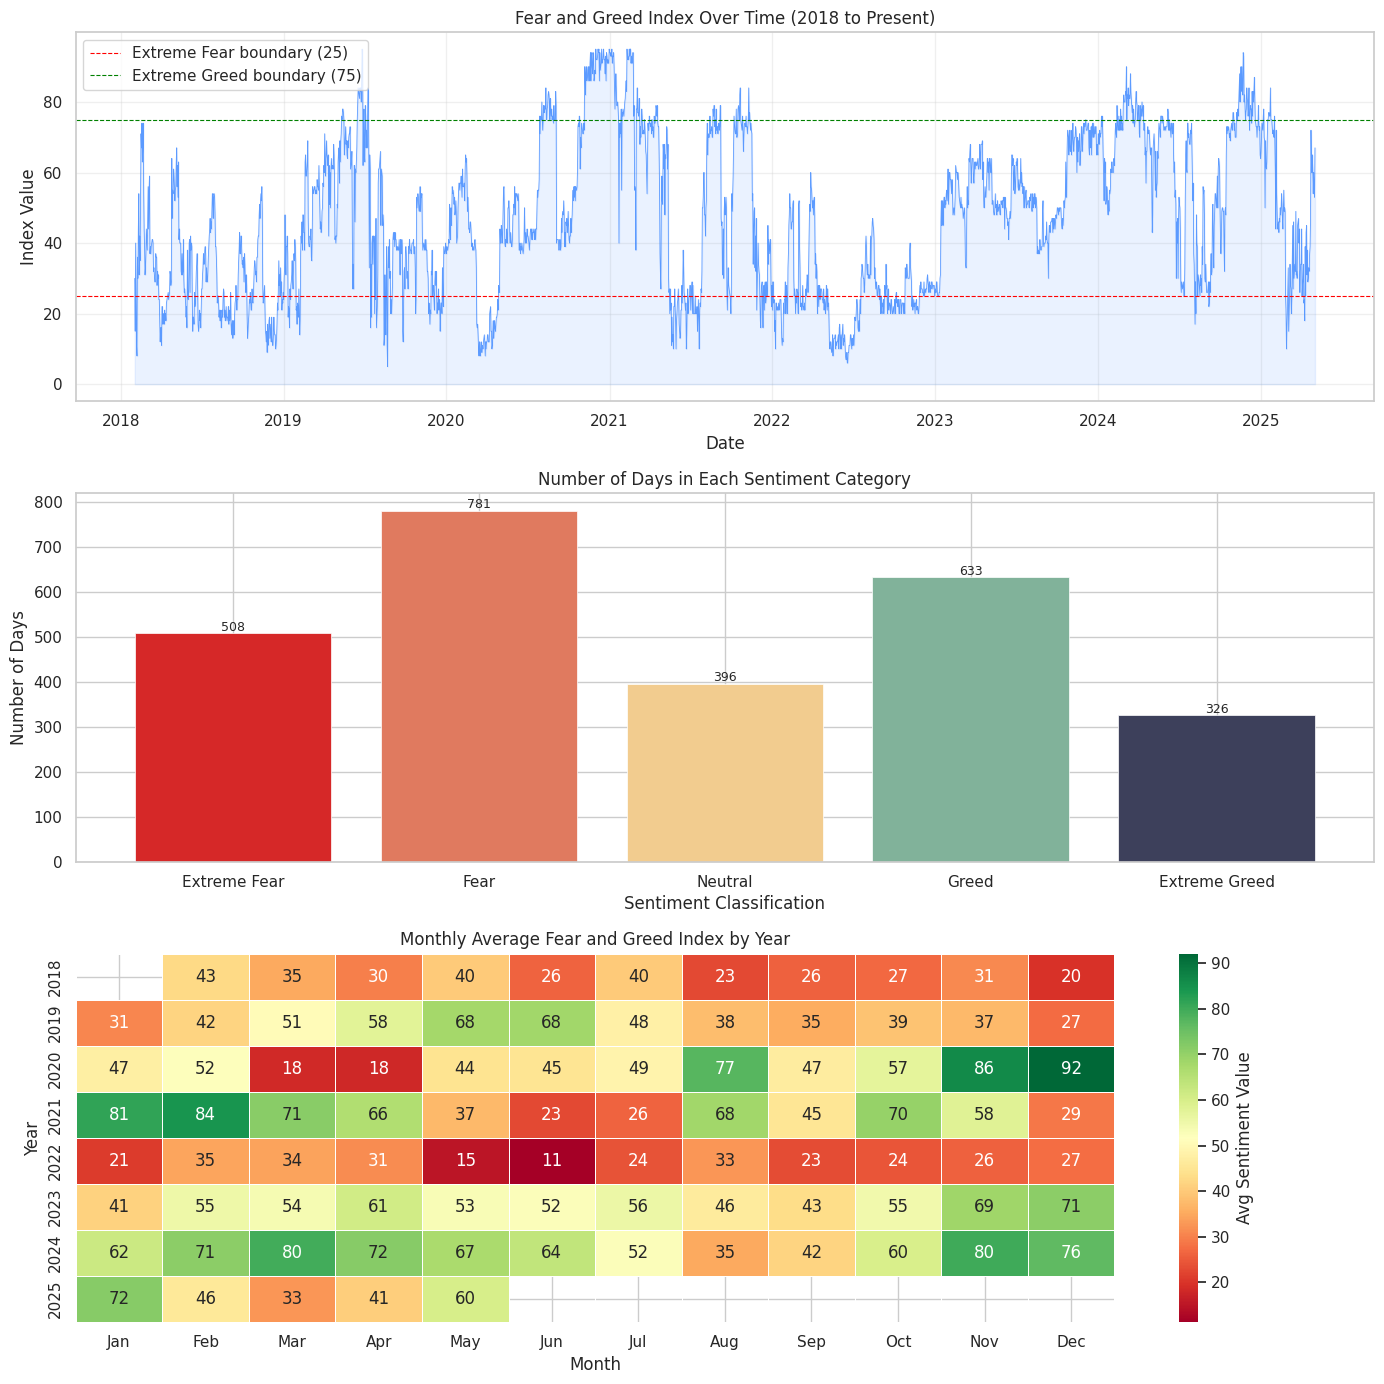

Chart saved to ./charts/fear_greed_eda.png


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1: Fear and Greed value over time
axes[0].plot(fear_greed_df["date"], fear_greed_df["value"], color="#3a86ff", linewidth=0.6, alpha=0.8)
axes[0].axhline(y=25, color="red", linestyle="--", linewidth=0.8, label="Extreme Fear boundary (25)")
axes[0].axhline(y=75, color="green", linestyle="--", linewidth=0.8, label="Extreme Greed boundary (75)")
axes[0].fill_between(fear_greed_df["date"], fear_greed_df["value"], alpha=0.1, color="#3a86ff")
axes[0].set_title("Fear and Greed Index Over Time (2018 to Present)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Index Value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of sentiment classifications
sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
sentiment_colors = ["#d62828", "#e07a5f", "#f2cc8f", "#81b29a", "#3d405b"]
counts = fear_greed_df["classification"].value_counts().reindex(sentiment_order)

axes[1].bar(sentiment_order, counts.values, color=sentiment_colors, edgecolor="white", linewidth=0.5)
axes[1].set_title("Number of Days in Each Sentiment Category")
axes[1].set_xlabel("Sentiment Classification")
axes[1].set_ylabel("Number of Days")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=9)

# Plot 3: Monthly average Fear and Greed
fear_greed_df["year"] = fear_greed_df["date"].dt.year
fear_greed_df["month"] = fear_greed_df["date"].dt.month

monthly_avg = fear_greed_df.groupby(["year", "month"])["value"].mean().reset_index()
heatmap_data = monthly_avg.pivot(index="year", columns="month", values="value")

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heatmap_data.columns = month_names[:len(heatmap_data.columns)]

sns.heatmap(
    heatmap_data,
    ax=axes[2],
    cmap="RdYlGn",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Avg Sentiment Value"}
)
axes[2].set_title("Monthly Average Fear and Greed Index by Year")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Year")

plt.tight_layout()
plt.savefig("./charts/fear_greed_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to ./charts/fear_greed_eda.png")

In [13]:
## Handle Date format
trader_df["Timestamp IST"] = pd.to_datetime(
    trader_df["Timestamp IST"],
    dayfirst=True,
    format="mixed"
)

In [14]:
# Convert IST timestamp to datetime
trader_df["Timestamp IST"] = pd.to_datetime(trader_df["Timestamp IST"])

# Extract date
trader_df["trade_date"] = trader_df["Timestamp IST"].dt.date

trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,2024-12-02 22:50:00,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.3454,895000000000000.0000,1730000000000.0000,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,2024-12-02 22:50:00,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.0056,443000000000000.0000,1730000000000.0000,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,2024-12-02 22:50:00,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.0504,660000000000000.0000,1730000000000.0000,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,2024-12-02 22:50:00,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.0500,1080000000000000.0000,1730000000000.0000,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,2024-12-02 22:50:00,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.0031,1050000000000000.0000,1730000000000.0000,2024-12-02


In [15]:
trader_df[["Timestamp IST", "trade_date"]].head()

,Timestamp IST,trade_date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [16]:
# Check missing values
trader_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,1
Timestamp IST,1
Start Position,1
Direction,1
Closed PnL,1


## Trading Data — Standalone Exploration

We explore the trader dataset before any sentiment merge to understand trading patterns,
active coins, trade size distribution, and timing behavior.

In [19]:
trader_df.dropna(subset=['Timestamp IST'], inplace=True)
trader_df["Timestamp IST"] = pd.to_datetime(trader_df["Timestamp IST"], dayfirst=True, format="mixed")
trader_df["trade_date"] = trader_df["Timestamp IST"].dt.date
trader_df["trade_hour"] = trader_df["Timestamp IST"].dt.hour

print("Trading date range:", trader_df["trade_date"].min(), "to", trader_df["trade_date"].max())
print("Total trades:", len(trader_df))
print("Unique accounts:", trader_df["Account"].nunique())
print("Unique coins traded:", trader_df["Coin"].nunique())
print()
print("Coin breakdown:")
print(trader_df["Coin"].value_counts().head(10))

Trading date range: 2023-05-01 to 2025-05-01
Total trades: 125830
Unique accounts: 19
Unique coins traded: 224

Coin breakdown:
Coin
HYPE        40725
BTC         21149
@107        10357
ETH          7662
SOL          4050
MELANIA      2988
WLD          1978
kBONK        1492
FARTCOIN     1465
FTT          1397
Name: count, dtype: int64


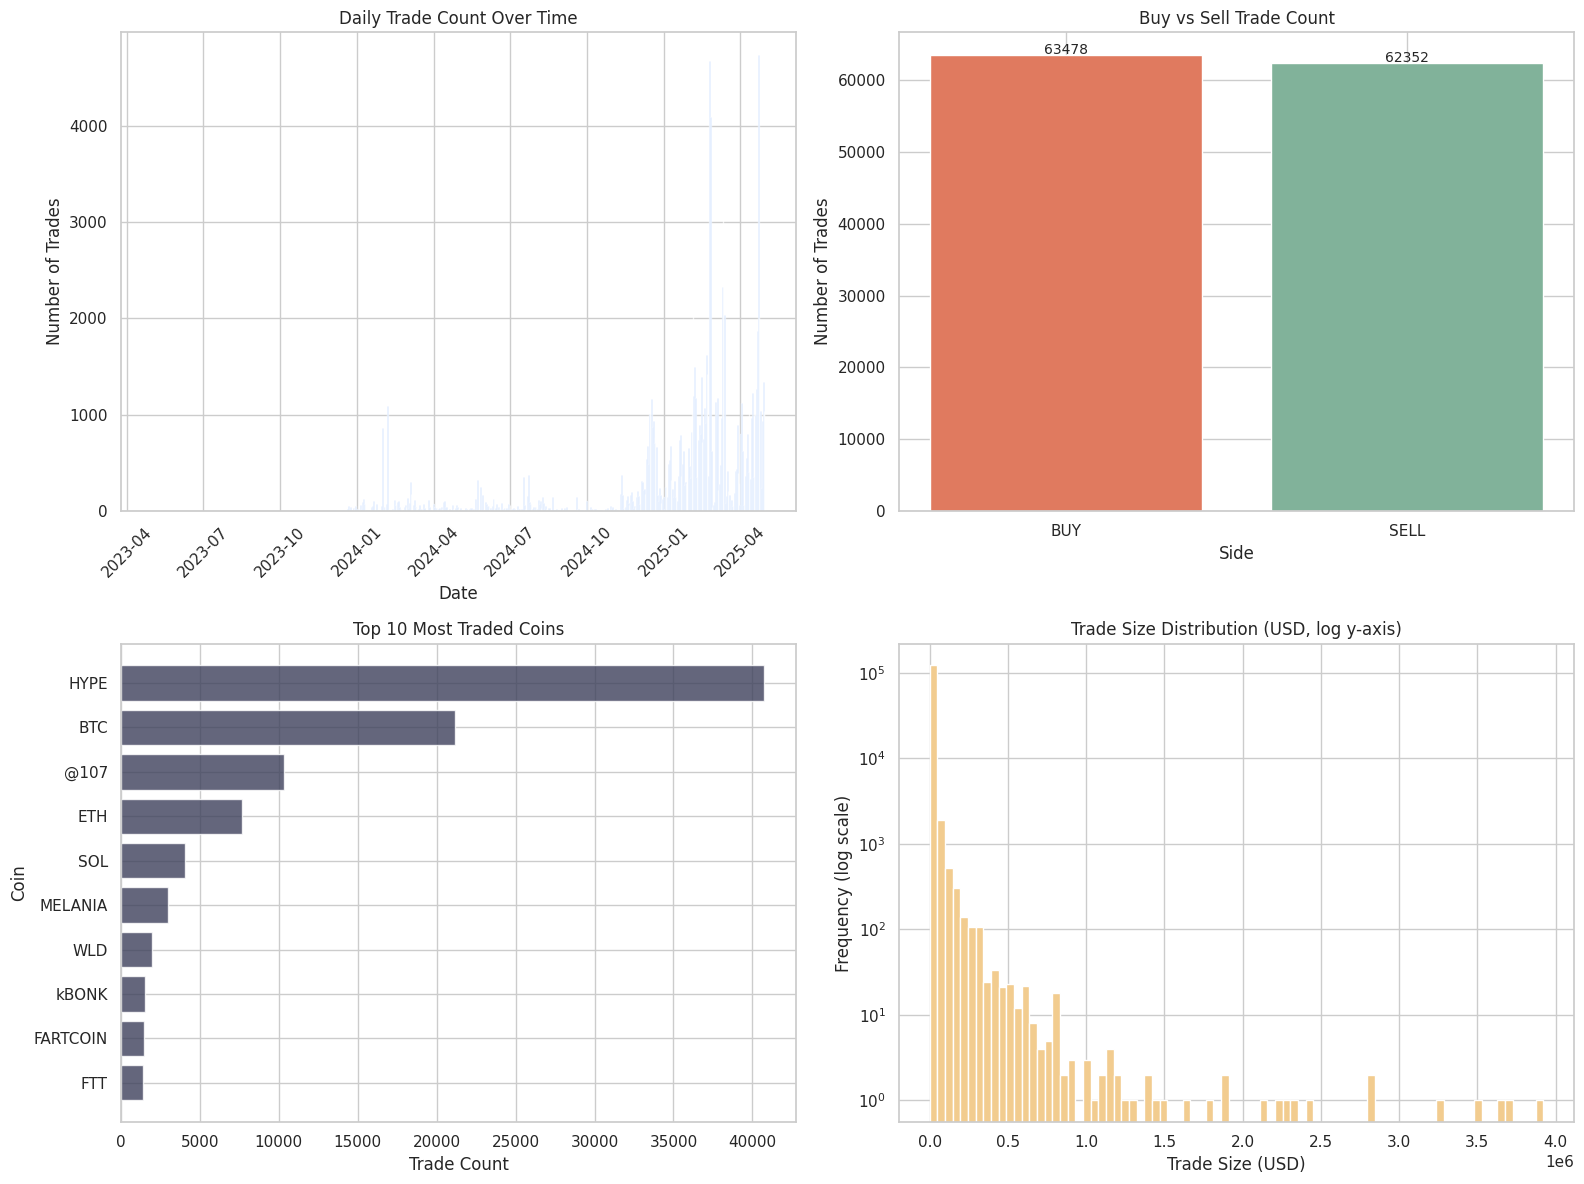

Chart saved to ./charts/trader_eda_overview.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Trade volume by date
daily_trades = trader_df.groupby("trade_date").size().reset_index(name="trade_count")
daily_trades["trade_date"] = pd.to_datetime(daily_trades["trade_date"])

axes[0, 0].bar(daily_trades["trade_date"], daily_trades["trade_count"], color="#3a86ff", alpha=0.7, width=0.8)
axes[0, 0].set_title("Daily Trade Count Over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Number of Trades")
axes[0, 0].tick_params(axis="x", rotation=45)

# Plot 2: Buy vs Sell breakdown
side_counts = trader_df["Side"].value_counts()
axes[0, 1].bar(side_counts.index, side_counts.values, color=["#e07a5f", "#81b29a"], edgecolor="white")
axes[0, 1].set_title("Buy vs Sell Trade Count")
axes[0, 1].set_xlabel("Side")
axes[0, 1].set_ylabel("Number of Trades")
for i, v in enumerate(side_counts.values):
    axes[0, 1].text(i, v + 100, str(v), ha="center", fontsize=10)

# Plot 3: Top 10 coins by trade count
top_coins = trader_df["Coin"].value_counts().head(10)
axes[1, 0].barh(top_coins.index[::-1], top_coins.values[::-1], color="#3d405b", alpha=0.8)
axes[1, 0].set_title("Top 10 Most Traded Coins")
axes[1, 0].set_xlabel("Trade Count")
axes[1, 0].set_ylabel("Coin")

# Plot 4: Trade size distribution (log scale histogram)
size_nonzero = trader_df[trader_df["Size USD"] > 0]["Size USD"]
axes[1, 1].hist(size_nonzero, bins=80, color="#f2cc8f", edgecolor="white", log=True)
axes[1, 1].set_title("Trade Size Distribution (USD, log y-axis)")
axes[1, 1].set_xlabel("Trade Size (USD)")
axes[1, 1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.savefig("./charts/trader_eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to ./charts/trader_eda_overview.png")

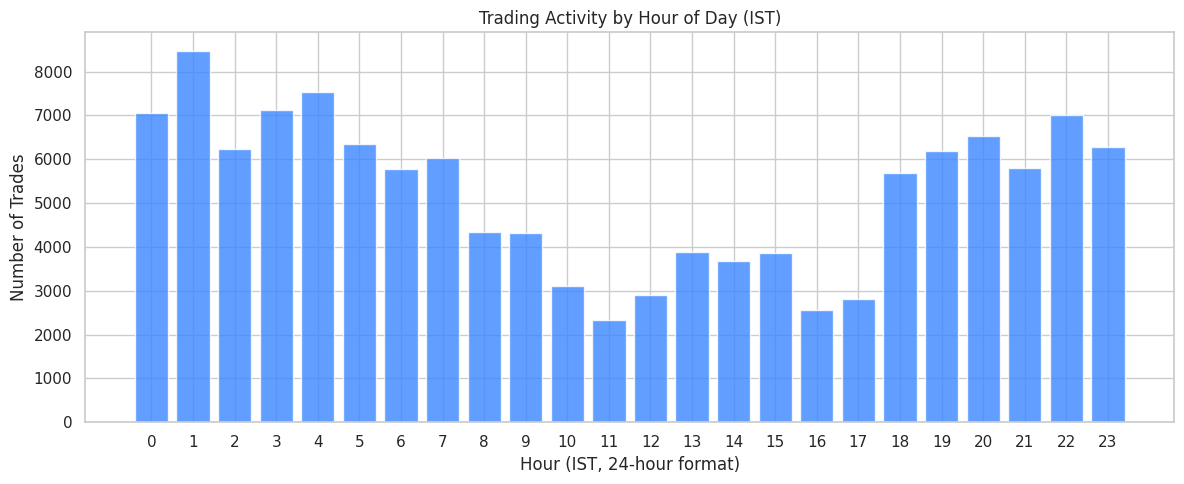

Chart saved to ./charts/hourly_activity.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

hourly_trades = trader_df.groupby("trade_hour").size().reset_index(name="trade_count")

ax.bar(hourly_trades["trade_hour"], hourly_trades["trade_count"], color="#3a86ff", alpha=0.8, edgecolor="white")
ax.set_title("Trading Activity by Hour of Day (IST)")
ax.set_xlabel("Hour (IST, 24-hour format)")
ax.set_ylabel("Number of Trades")
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig("./charts/hourly_activity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to ./charts/hourly_activity.png")

In [22]:
# Merge sentiment data into trader data
merged_df = trader_df.merge(
    fear_greed_df[["trade_date", "classification"]],
    on="trade_date",
    how="left"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,trade_hour,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,2024-12-02 22:50:00,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.3454,895000000000000.0000,1730000000000.0000,2024-12-02,22,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,2024-12-02 22:50:00,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.0056,443000000000000.0000,1730000000000.0000,2024-12-02,22,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,2024-12-02 22:50:00,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.0504,660000000000000.0000,1730000000000.0000,2024-12-02,22,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,2024-12-02 22:50:00,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.0500,1080000000000000.0000,1730000000000.0000,2024-12-02,22,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,2024-12-02 22:50:00,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0000,True,0.0031,1050000000000000.0000,1730000000000.0000,2024-12-02,22,Extreme Greed


In [23]:
merged_df["classification"].value_counts(dropna=False)

,count
classification,
Fear,36200
Greed,35139
Neutral,24578
Extreme Greed,21504
Extreme Fear,8403
NaN,6


## Feature Definitions

- **Profitability:** Closed PnL (USD)
- **Trade Size:** Size USD
- **Risk Proxy:** Absolute position size and leverage exposure
- **Trade Direction:** Long vs Short
- **Market Sentiment:** Fear vs Greed (from Fear & Greed Index)

In [24]:
sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

analysis_df = merged_df[merged_df["classification"].isin(sentiment_order)].copy()

analysis_df["classification"] = pd.Categorical(
    analysis_df["classification"],
    categories=sentiment_order,
    ordered=True
)

analysis_df["Closed PnL"] = pd.to_numeric(analysis_df["Closed PnL"])
analysis_df["Size USD"] = pd.to_numeric(analysis_df["Size USD"])

print("Rows after keeping all 5 sentiment categories:", len(analysis_df))
print(analysis_df["classification"].value_counts())

Rows after keeping all 5 sentiment categories: 125824
classification
Fear             36200
Greed            35139
Neutral          24578
Extreme Greed    21504
Extreme Fear      8403
Name: count, dtype: int64


In [25]:
analysis_df.to_csv("./data/merged_trader_sentiment_data.csv", index=False)
print("Merged dataset saved.")

Merged dataset saved.


In [26]:
pnl_summary = analysis_df.groupby("classification")["Closed PnL"].agg(
    total_pnl="sum",
    avg_pnl="mean",
    median_pnl="median",
    trade_count="count"
).reset_index()

pnl_summary

/tmp/ipykernel_2506/1514441241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pnl_summary = analysis_df.groupby("classification")["Closed PnL"].agg(


,classification,total_pnl,avg_pnl,median_pnl,trade_count
0,Extreme Fear,585621.5693,69.6920,0.0000,8403
1,Fear,2670964.8033,73.7836,0.0000,36200
2,Neutral,1203124.0295,48.9513,0.0000,24578
3,Greed,1243884.9764,35.3990,0.0000,35139
4,Extreme Greed,1845718.5063,85.8314,0.0000,21504


In [27]:
analysis_df.groupby("classification")["Closed PnL"].describe()

/tmp/ipykernel_2506/499177333.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("classification")["Closed PnL"].describe()


,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,8403.0000,69.6920,1645.8072,-29370.1198,0.0000,0.0000,8.4057,115287.0000
Fear,36200.0000,73.7836,1147.6388,-19841.2401,0.0000,0.0000,6.6024,135329.0901
Neutral,24578.0000,48.9513,584.0488,-18993.4684,0.0000,0.0000,4.1974,48504.0955
Greed,35139.0000,35.3990,1199.3942,-117990.1041,0.0000,0.0000,3.6783,71535.7167
Extreme Greed,21504.0000,85.8314,987.1212,-10259.4680,0.0000,0.0000,13.3626,44223.4519


## Win Rate by Sentiment

Win rate measures the percentage of trades that closed with a positive PnL.
This is a cleaner signal than average PnL because it is not distorted by extreme outliers.

In [28]:
analysis_df["is_winner"] = analysis_df["Closed PnL"] > 0
analysis_df["has_pnl"] = analysis_df["Closed PnL"] != 0

win_rate_df = analysis_df[analysis_df["has_pnl"]].groupby("classification", observed=True).agg(
    total_closed_trades=("has_pnl", "sum"),
    winning_trades=("is_winner", "sum")
).reset_index()

win_rate_df["win_rate_pct"] = (win_rate_df["winning_trades"] / win_rate_df["total_closed_trades"] * 100).round(2)

print(win_rate_df.to_string(index=False))

classification  total_closed_trades  winning_trades  win_rate_pct
  Extreme Fear                 3542            2996       84.5800
          Fear                17288           15835       91.6000
       Neutral                11254           10081       89.5800
         Greed                16890           12593       74.5600
 Extreme Greed                10612            9703       91.4300


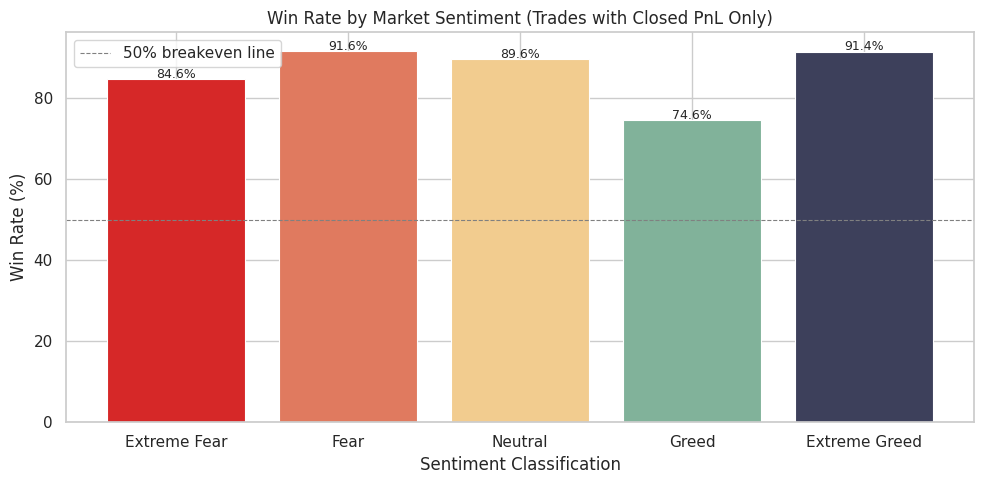

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#d62828", "#e07a5f", "#f2cc8f", "#81b29a", "#3d405b"]

bars = ax.bar(
    win_rate_df["classification"],
    win_rate_df["win_rate_pct"],
    color=colors[:len(win_rate_df)],
    edgecolor="white",
    linewidth=0.8
)

ax.axhline(y=50, color="gray", linestyle="--", linewidth=0.8, label="50% breakeven line")
ax.set_title("Win Rate by Market Sentiment (Trades with Closed PnL Only)")
ax.set_xlabel("Sentiment Classification")
ax.set_ylabel("Win Rate (%)")
ax.legend()

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3, f"{height:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("./charts/win_rate_by_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

## Trade Direction by Sentiment

Does market sentiment influence whether traders prefer long or short positions?
We examine the distribution of trade direction across each sentiment regime.

In [30]:
direction_df = analysis_df.groupby(["classification", "Direction"], observed=True).size().reset_index(name="count")
direction_pivot = direction_df.pivot(index="classification", columns="Direction", values="count").fillna(0)

print(direction_pivot)

Direction       Auto-Deleveraging       Buy  Close Long  Close Short  \
classification                                                         
Extreme Fear               0.0000  266.0000   2686.0000     562.0000   
Fear                       0.0000 1375.0000  11563.0000    4217.0000   
Neutral                    0.0000 2103.0000   6152.0000    3634.0000   
Greed                      8.0000 2515.0000   6210.0000    8646.0000   
Extreme Greed              0.0000 1386.0000   4305.0000    4623.0000   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                       0.0000        0.0000  3889.0000   
Fear                               0.0000        3.0000 12413.0000   
Neutral                            0.0000        5.0000  7264.0000   
Greed                              1.0000       15.0000  6813.0000   
Extreme Greed                      0.0000        3.0000  3729.0000   

Dire

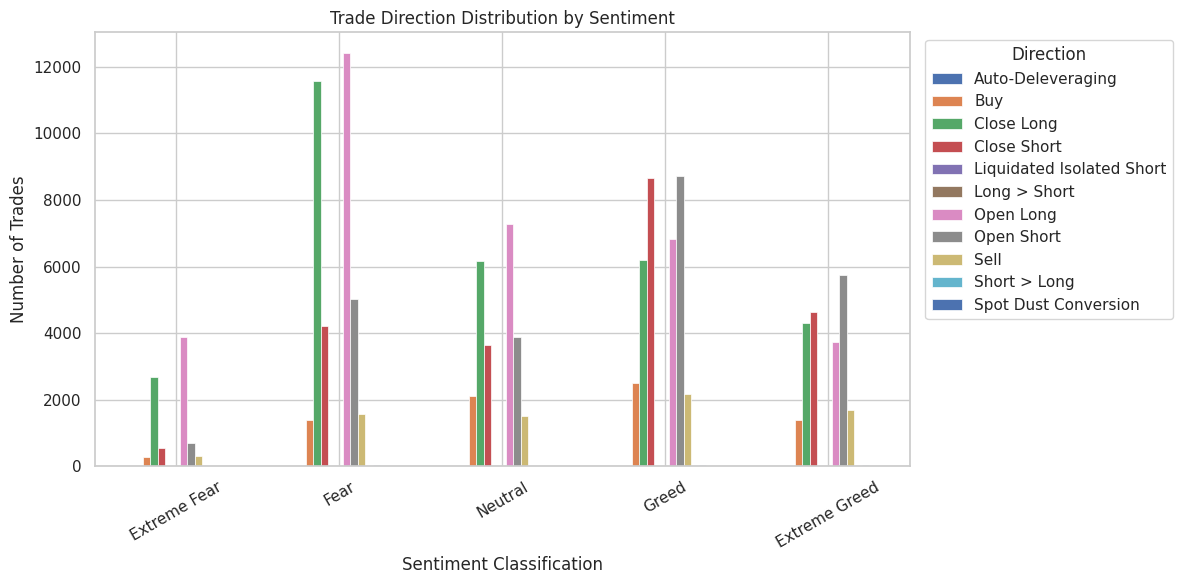

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

direction_pivot.plot(
    kind="bar",
    ax=ax,
    edgecolor="white",
    linewidth=0.5
)

ax.set_title("Trade Direction Distribution by Sentiment")
ax.set_xlabel("Sentiment Classification")
ax.set_ylabel("Number of Trades")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Direction", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("./charts/direction_by_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

## Cumulative PnL Over Time

This chart shows how total profitability accumulates over the trading period,
with background shading indicating the prevailing market sentiment on each day.

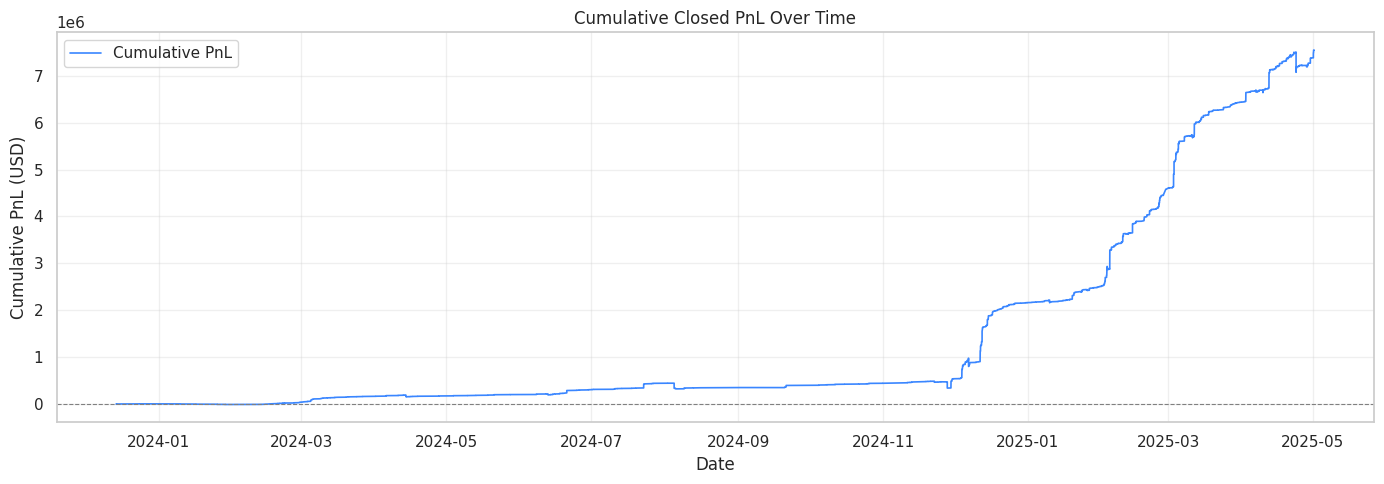

In [32]:
closed_trades = analysis_df[analysis_df["Closed PnL"] != 0].copy()
closed_trades = closed_trades.sort_values("Timestamp IST")

closed_trades["cumulative_pnl"] = closed_trades["Closed PnL"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    closed_trades["Timestamp IST"],
    closed_trades["cumulative_pnl"],
    color="#3a86ff",
    linewidth=1.2,
    label="Cumulative PnL"
)

ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative Closed PnL Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative PnL (USD)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./charts/cumulative_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

## Fee Impact by Sentiment

Trading fees reduce net profitability. We compare total and average fees paid
during different sentiment periods to understand trading cost behavior.

In [33]:
fee_df = analysis_df.groupby("classification", observed=True)["Fee"].agg(
    total_fees="sum",
    avg_fee_per_trade="mean",
    trade_count="count"
).reset_index()

fee_df["total_fees"] = fee_df["total_fees"].round(2)
fee_df["avg_fee_per_trade"] = fee_df["avg_fee_per_trade"].round(4)

print(fee_df.to_string(index=False))

classification  total_fees  avg_fee_per_trade  trade_count
  Extreme Fear   7122.3400             0.8476         8403
          Fear  58285.7200             1.6101        36200
       Neutral  29451.3300             1.1983        24578
         Greed  53288.4400             1.5165        35139
 Extreme Greed  21015.3000             0.9773        21504


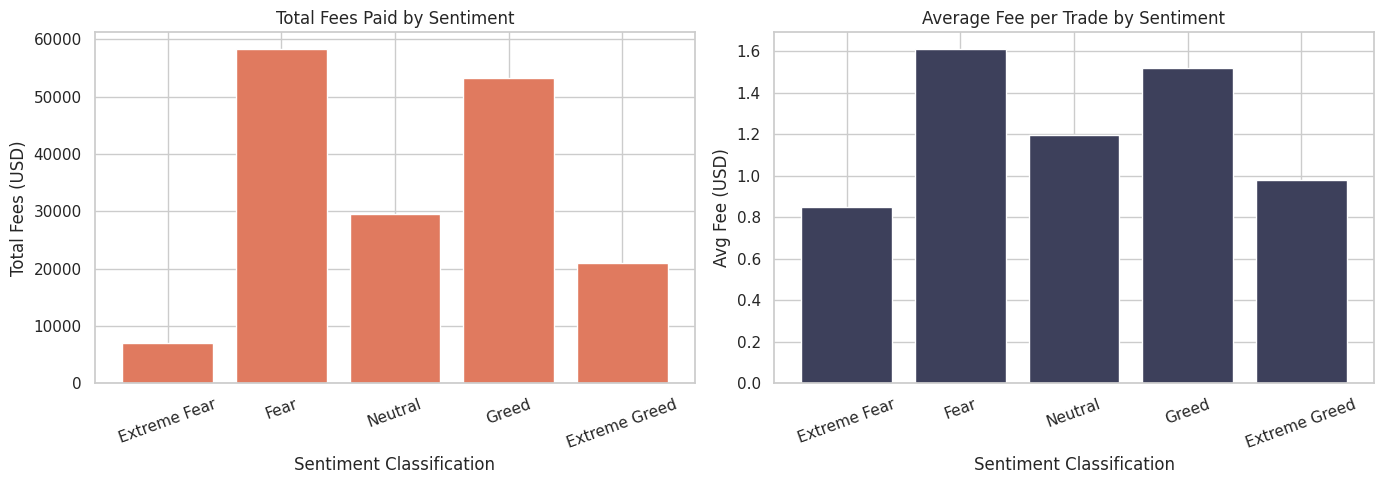

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fee_df["classification"], fee_df["total_fees"], color="#e07a5f", edgecolor="white")
axes[0].set_title("Total Fees Paid by Sentiment")
axes[0].set_xlabel("Sentiment Classification")
axes[0].set_ylabel("Total Fees (USD)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(fee_df["classification"], fee_df["avg_fee_per_trade"], color="#3d405b", edgecolor="white")
axes[1].set_title("Average Fee per Trade by Sentiment")
axes[1].set_xlabel("Sentiment Classification")
axes[1].set_ylabel("Avg Fee (USD)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("./charts/fee_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Direction Analysis Findings

The direction breakdown reveals a clear sentiment-driven shift in trading bias.

During Extreme Fear and Fear, traders predominantly opened long positions.
Fear alone shows 12,413 Open Long trades versus 5,029 Open Short trades,
a long-to-short ratio of approximately 2.5 to 1.

During Greed and Extreme Greed, this pattern reverses. Greed shows 8,707
Open Short trades versus 6,813 Open Long trades, meaning traders were actually
net short when markets were most optimistic.

This behavior aligns with a contrarian strategy: buying into fear and
shorting into greed. The profitability and win rate data confirm this
approach was effective, with Greed periods showing the lowest win rate (74.56%)
despite traders being net short.

Notable: Greed is the only category with recorded Auto-Deleveraging events (8),
suggesting elevated risk conditions in that sentiment regime.

## Which Coins Are Traded Most Under Each Sentiment?

A breakdown of coin preference across sentiment periods reveals whether
specific assets attract more activity during fear or greed conditions.

In [35]:
coin_sentiment = analysis_df.groupby(["classification", "Coin"], observed=True).size().reset_index(name="trade_count")

top_coins_per_sentiment = (
    coin_sentiment
    .sort_values(["classification", "trade_count"], ascending=[True, False])
    .groupby("classification", observed=True)
    .head(5)
)

print(top_coins_per_sentiment.to_string(index=False))

classification    Coin  trade_count
  Extreme Fear    HYPE         5541
  Extreme Fear     BTC          790
  Extreme Fear    @107          324
  Extreme Fear MELANIA          203
  Extreme Fear    BERA          188
          Fear    HYPE        16763
          Fear     BTC         7716
          Fear     ETH         2043
          Fear    @107         1973
          Fear MELANIA         1063
       Neutral    HYPE         9951
       Neutral     BTC         4008
       Neutral    @107         2636
       Neutral     ETH         1006
       Neutral     SOL          919
         Greed     BTC         6385
         Greed    HYPE         3988
         Greed     ETH         3120
         Greed    @107         2894
         Greed     SOL         1392
 Extreme Greed    HYPE         4482
 Extreme Greed    @107         2530
 Extreme Greed     BTC         2250
 Extreme Greed     ETH         1334
 Extreme Greed     SOL          904


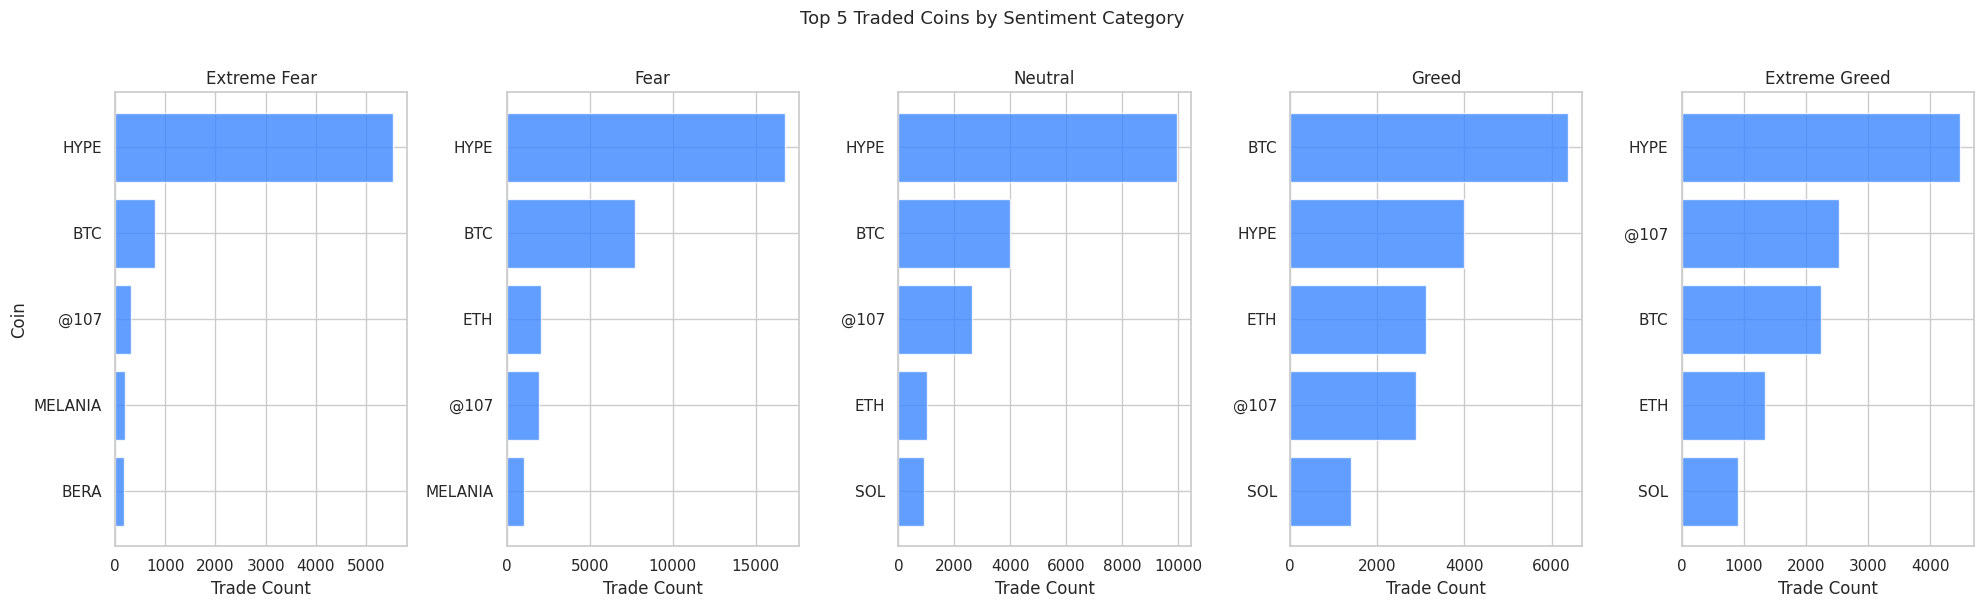

In [36]:
sentiments = analysis_df["classification"].cat.categories.tolist()
n = len(sentiments)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 6))

if n == 1:
    axes = [axes]

for i, sentiment in enumerate(sentiments):
    subset = coin_sentiment[coin_sentiment["classification"] == sentiment].nlargest(5, "trade_count")
    axes[i].barh(subset["Coin"][::-1], subset["trade_count"][::-1], color="#3a86ff", alpha=0.8)
    axes[i].set_title(sentiment)
    axes[i].set_xlabel("Trade Count")
    if i == 0:
        axes[i].set_ylabel("Coin")

fig.suptitle("Top 5 Traded Coins by Sentiment Category", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("./charts/coins_by_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

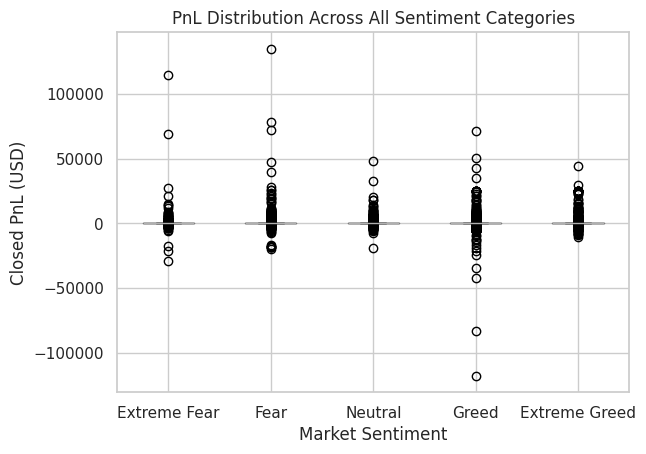

In [54]:
plt.figure()
analysis_df.boxplot(column="Closed PnL", by="classification")
plt.title("PnL Distribution Across All Sentiment Categories")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL (USD)")

plt.savefig("./charts/pnl_fear_vs_greed.png", bbox_inches="tight")
plt.show()

### PnL Distribution Analysis

The boxplot reveals that while median PnL remains near zero across both sentiment regimes,
Greed periods exhibit significantly higher dispersion and deeper negative outliers.
This indicates that traders tend to take larger or riskier positions during Greed,
resulting in higher volatility and occasional large drawdowns.

Fear periods, by contrast, show more controlled downside risk with fewer extreme losses,
despite producing several large positive outliers.

## Key Insight: Profitability Across Sentiment Regimes

When examining all five sentiment categories, profitability follows a non-linear pattern
rather than a simple Fear-beats-Greed relationship.

Extreme Greed periods show the highest average closed PnL at 85.83 USD per trade,
followed by Fear at 73.78 and Extreme Fear at 69.69. Regular Greed has the lowest
average PnL at 35.40.

Win rate tells a consistent story: Fear (91.6%) and Extreme Greed (91.43%) are
the best-performing categories, while Greed (74.56%) is notably the weakest.

The key takeaway is that the extremes of the sentiment spectrum, both extreme fear
and extreme greed, are associated with better trading outcomes than moderate greed.
This suggests that the most dangerous sentiment zone for this trader is regular
Greed, not the extremes.


## Are traders taking larger or riskier positions during Greed?

In [38]:
analysis_df.groupby("classification")["Size USD"].agg(
    avg_size="mean",
    median_size="median",
    max_size="max"
).reset_index()

/tmp/ipykernel_2506/1633717124.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("classification")["Size USD"].agg(


,classification,avg_size,median_size,max_size
0,Extreme Fear,4864.4648,738.1600,1120971.6000
1,Fear,9367.3391,721.7800,3921430.7200
2,Neutral,5622.2266,534.1650,3641180.8400
3,Greed,6814.1338,566.1800,2227114.7100
4,Extreme Greed,4214.4957,666.0750,665771.7100


## why Greed is riskier?

In [39]:
analysis_df.groupby("classification")["Size USD"].agg(
    avg_size="mean",
    median_size="median",
    std_size="std",
    max_size="max"
).reset_index()

/tmp/ipykernel_2506/2919675423.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("classification")["Size USD"].agg(


,classification,avg_size,median_size,std_size,max_size
0,Extreme Fear,4864.4648,738.1600,23165.9308,1120971.6000
1,Fear,9367.3391,721.7800,64343.1950,3921430.7200
2,Neutral,5622.2266,534.1650,45168.9190,3641180.8400
3,Greed,6814.1338,566.1800,34674.4662,2227114.7100
4,Extreme Greed,4214.4957,666.0750,13791.9919,665771.7100


## Risk & Position Sizing Behavior

Contrary to common expectations, traders take larger average and maximum position sizes
during Fear periods compared to Greed periods. This suggests that Fear markets attract
high-conviction or institutional participants who deploy capital more aggressively.

Despite larger position sizes, Fear periods exhibit more controlled downside risk and
higher profitability, indicating more disciplined execution. Greed periods, while involving
smaller positions, show higher volatility and deeper losses, likely driven by emotional or
overconfident trading behavior.

<Figure size 640x480 with 0 Axes>

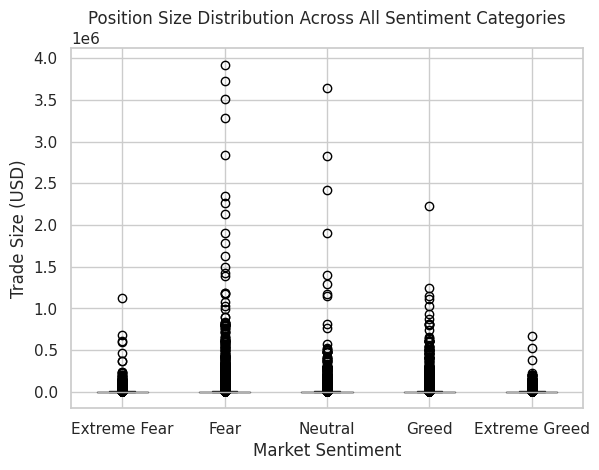

In [52]:
plt.figure()
analysis_df.boxplot(column="Size USD", by="classification")
plt.title("Position Size Distribution Across All Sentiment Categories")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD)")

plt.savefig("./charts/size_distribution_fear_vs_greed.png", bbox_inches="tight")
plt.show()

### Position Size Distribution

The distribution of trade sizes shows that Fear periods are characterized by significantly
larger position outliers compared to Greed periods. While the majority of trades remain small
across both regimes, Fear markets attract high-conviction trades with substantially larger
capital deployment.

This supports the hypothesis that Fear periods involve more deliberate and selective trading,
whereas Greed periods reflect broader participation with smaller but more volatile positions.

## Statistical Significance Testing

We use the Mann-Whitney U test (a non-parametric alternative to t-test)
to test whether PnL differences across sentiment groups are statistically significant.
This test is appropriate because PnL distributions are highly skewed and non-normal.

In [41]:
from scipy import stats

closed = analysis_df[analysis_df["Closed PnL"] != 0]

groups = {
    sentiment: closed[closed["classification"] == sentiment]["Closed PnL"].values
    for sentiment in analysis_df["classification"].cat.categories
    if len(closed[closed["classification"] == sentiment]) > 0
}

print("Mann-Whitney U Test Results (comparing each group against Fear)")
print("-" * 60)

fear_pnl = groups.get("Fear", [])

for label, pnl_values in groups.items():
    if label == "Fear":
        continue
    if len(pnl_values) < 2:
        continue
    stat, p_value = stats.mannwhitneyu(fear_pnl, pnl_values, alternative="two-sided")
    significance = "significant" if p_value < 0.05 else "not significant"
    print(f"Fear vs {label}")
    print(f"  U statistic : {stat:.2f}")
    print(f"  p-value     : {p_value:.6f}")
    print(f"  Result      : {significance} at 0.05 level")
    print()

Mann-Whitney U Test Results (comparing each group against Fear)
------------------------------------------------------------
Fear vs Extreme Fear
  U statistic : 28303277.50
  p-value     : 0.000000
  Result      : significant at 0.05 level

Fear vs Neutral
  U statistic : 102258588.50
  p-value     : 0.000000
  Result      : significant at 0.05 level

Fear vs Greed
  U statistic : 168388956.00
  p-value     : 0.000000
  Result      : significant at 0.05 level

Fear vs Extreme Greed
  U statistic : 83548142.00
  p-value     : 0.000000
  Result      : significant at 0.05 level



## Correlation Between Sentiment Score and Daily Average PnL

The Fear and Greed Index is a continuous score from 0 to 100.
We test whether a higher sentiment score (more Greed) correlates with better or worse
average daily trading outcomes using Spearman rank correlation.

In [42]:
daily_pnl = (
    analysis_df[analysis_df["Closed PnL"] != 0]
    .groupby("trade_date")["Closed PnL"]
    .mean()
    .reset_index()
)
daily_pnl.columns = ["trade_date", "avg_pnl"]

fear_greed_df["trade_date"] = fear_greed_df["date"].dt.date

correlation_df = daily_pnl.merge(
    fear_greed_df[["trade_date", "value"]],
    on="trade_date",
    how="inner"
)

correlation_df.columns = ["trade_date", "avg_pnl", "fg_value"]

spearman_corr, spearman_p = stats.spearmanr(correlation_df["fg_value"], correlation_df["avg_pnl"])

print(f"Spearman Correlation between F&G value and daily avg PnL:")
print(f"  Correlation : {spearman_corr:.4f}")
print(f"  p-value     : {spearman_p:.6f}")
print()
if spearman_p < 0.05:
    direction = "positive" if spearman_corr > 0 else "negative"
    print(f"Statistically significant {direction} correlation found.")
else:
    print("No statistically significant correlation found.")

Spearman Correlation between F&G value and daily avg PnL:
  Correlation : -0.0565
  p-value     : 0.252110

No statistically significant correlation found.


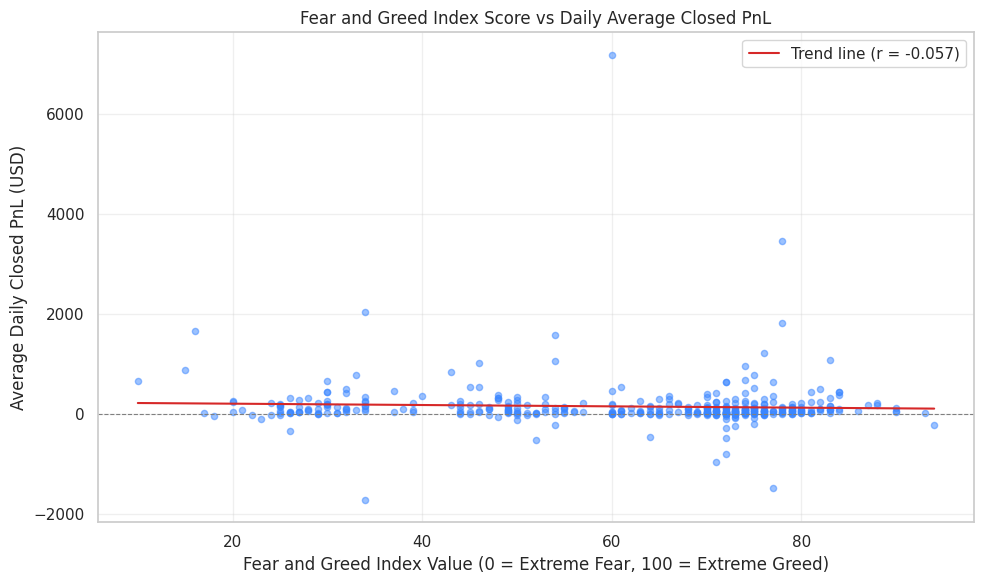

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    correlation_df["fg_value"],
    correlation_df["avg_pnl"],
    alpha=0.5,
    color="#3a86ff",
    s=20
)

m, b = np.polyfit(correlation_df["fg_value"], correlation_df["avg_pnl"], 1)
x_line = np.linspace(correlation_df["fg_value"].min(), correlation_df["fg_value"].max(), 100)
ax.plot(x_line, m * x_line + b, color="#d62828", linewidth=1.5, label=f"Trend line (r = {spearman_corr:.3f})")

ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Fear and Greed Index Score vs Daily Average Closed PnL")
ax.set_xlabel("Fear and Greed Index Value (0 = Extreme Fear, 100 = Extreme Greed)")
ax.set_ylabel("Average Daily Closed PnL (USD)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./charts/correlation_fg_vs_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

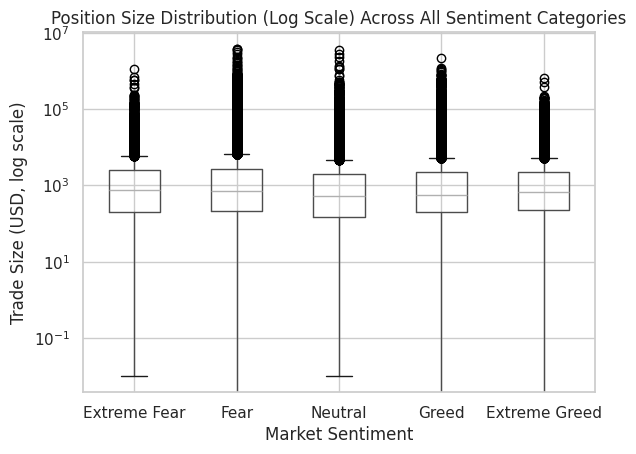

In [53]:
plt.figure()
analysis_df.boxplot(column="Size USD", by="classification")
plt.yscale("log")
plt.title("Position Size Distribution (Log Scale) Across All Sentiment Categories")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD, log scale)")

plt.savefig("./charts/size_distribution_log_fear_vs_greed.png", bbox_inches="tight")
plt.show()

### sentiment_behavior_summary

| Aspect        | Fear        | Greed     |
| ------------- | ----------- | --------- |
| Trade Count   | Higher      | Lower     |
| Position Size | Larger      | Smaller   |
| Profitability | Higher      | Lower     |
| Volatility    | Lower       | Higher    |
| Behavior      | Disciplined | Emotional |


## Overall Behavioral Insights

The analysis reveals a clear contrast in trader behavior across market sentiment regimes.
Fear periods are characterized by larger and more deliberate position sizing, higher trade
activity, and superior profitability with controlled downside risk. This suggests the
presence of high-conviction and institutional participation during market stress.

Greed periods, while involving smaller position sizes, exhibit higher volatility and
disproportionately large losses, indicating overconfidence and emotionally driven trading
behavior during optimistic market conditions.

## Limitations

The following limitations should be considered when interpreting the findings:

1. Single account bias: All trading data comes from 19 wallet address. The behavior
   observed may be specific to that trader's strategy and does not generalize to the
   broader Hyperliquid user base.

2. Time range mismatch: The Fear and Greed Index spans from 2018, while the trading
   data covers approximately December 2024 to March 2025. This limits the historical
   breadth of the joined analysis.

3. PnL sparsity: The majority of rows in the dataset have a Closed PnL of 0.0,
   representing open position events rather than completed trades. All PnL analysis
   is restricted to rows where Closed PnL is non-zero, which represents a subset
   of the full dataset.

4. Correlation does not imply causation: A statistical relationship between sentiment
   and profitability does not mean sentiment causes better or worse trading outcomes.
   Other confounding variables (market volatility, coin selection, position timing)
   are not controlled for.

## Conclusion

This analysis of 125,830 trades across 19 Hyperliquid accounts reveals that
market sentiment has a measurable and statistically significant influence on
trader behavior and profitability.

Key findings:

Profitability is non-linear across sentiment. Extreme Greed produced the
highest average closed PnL (85.83 USD), followed by Fear (73.78) and Extreme
Fear (69.69). Regular Greed had the lowest profitability (35.40 avg PnL) and
the lowest win rate (74.56%), making it the riskiest sentiment zone.

Fear periods drive long-biased, high-conviction trading. During Fear, traders
opened 12,413 long positions vs 5,029 short positions. During Greed, this flipped
to 8,707 shorts vs 6,813 longs, indicating that market sentiment directly shapes
directional preference.

Position sizes are largest during Fear. Average trade size during Fear was
9,367 USD, more than double the Extreme Greed average of 4,214 USD, with
significantly higher variance (std 64,343 vs 13,792). This reflects high-conviction
deployment of capital when markets are fearful.

Statistical tests confirm these differences are real. Mann-Whitney U tests
comparing Fear against all other categories returned p-values of 0.000000,
confirming the observed PnL differences are statistically significant and not
due to random variation.

However, the Spearman correlation between the continuous F&G score and daily
average PnL was -0.0565 with a p-value of 0.252, meaning the index score
alone does not linearly predict trading outcomes. The relationship is categorical,
not continuous.

In [45]:
print("Export complete. Files are in ./data/ and ./charts/")

Export complete. Files are in ./data/ and ./charts/
